# Install and Import Dependencies

In [1]:
!pip install tensorflow opencv-python mediapipe scikit-learn matplotlib tensorflowjs

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621


In [2]:
import sys
import subprocess
# Ensure required packages are installed into the notebook's Python environment
try:
    import cv2
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'opencv-python', 'mediapipe', 'scikit-learn', 'matplotlib'])
    import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

TypeError: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates

In [3]:
# Verification / safety cell: ensure mediapipe helpers are defined
import sys
import builtins
import numpy as np
import cv2
import mediapipe as mp
# Define mp_holistic/mp_drawing if not already defined in this kernel
if 'mp_holistic' not in globals():
    mp_holistic = mp.solutions.holistic
    mp_drawing = mp.solutions.drawing_utils
    globals()['mp_holistic'] = mp_holistic
    globals()['mp_drawing'] = mp_drawing
print('Verification:')
print('  python executable:', sys.executable)
print('  cv2 version:', cv2.__version__)
print('  mp_holistic defined:', 'mp_holistic' in globals())
print('  mp_drawing defined:', 'mp_drawing' in globals())

TypeError: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates

# Keypoints using MP Holistic

In [5]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [6]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR-CONVERSION BGR-to-RGB
    image.flags.writeable = False                  # Convert image to not-writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Convert image to writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR-COVERSION RGB-to-BGR
    return image, results

In [7]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [8]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [9]:
# Safety: define mediapipe helpers if they're missing in this kernel
import cv2
import mediapipe as mp
import numpy as np

if 'mediapipe_detection' not in globals():
    def mediapipe_detection(image, model):
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        results = model.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        return image, results
    globals()['mediapipe_detection'] = mediapipe_detection

if 'draw_styled_landmarks' not in globals():
    def draw_styled_landmarks(image, results):
        try:
            mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
                                      mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
                                      mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1))
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
                                      mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2))
            mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                                      mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2))
            mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                      mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        except Exception:
            pass
    globals()['draw_styled_landmarks'] = draw_styled_landmarks

if 'extract_keypoints' not in globals():
    def extract_keypoints(results):
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
        face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
        lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
        rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
        return np.concatenate([pose, face, lh, rh])
    globals()['extract_keypoints'] = extract_keypoints

print('Helpers available:', 
      'mediapipe_detection' in globals(), 
      'draw_styled_landmarks' in globals(), 
      'extract_keypoints' in globals())

Helpers available: True True True


In [10]:
from pathlib import Path
import numpy as np

# force set exactly what you want
actions = np.array(['cat', 'food', 'help'], dtype=object)
signs = list(actions)

# re-define DATA_PATH / numeric defaults if needed (keeps existing if already set)
DATA_PATH = Path(globals().get('DATA_PATH', 'MP_Data'))
DATA_PATH.mkdir(parents=True, exist_ok=True)

no_sequences = int(globals().get('no_sequences', 30))
sequence_length = int(globals().get('sequence_length', 30))
start_folder = int(globals().get('start_folder', 0))

# recreate folders for a clean test (be careful: this will create folders that might already exist)
def create_action_folders(base_path, actions_list, start_index, count, make_folders=True):
    created = []
    for action in actions_list:
        action_dir = base_path / action
        if make_folders:
            action_dir.mkdir(parents=True, exist_ok=True)
        for i in range(start_index, start_index + count):
            seq_dir = action_dir / str(i)
            if make_folders:
                seq_dir.mkdir(parents=True, exist_ok=True)
            created.append(seq_dir)
    return created

action_sequence_paths = create_action_folders(DATA_PATH, signs, start_folder, no_sequences, make_folders=True)

print("Reset performed.")
print("actions:", list(actions))
print("signs:", signs)
print("DATA_PATH:", DATA_PATH.resolve())
print("Created sequence folders (count):", len(action_sequence_paths))

Reset performed.
actions: ['cat', 'food', 'help']
signs: ['cat', 'food', 'help']
DATA_PATH: /Users/akashgpatil/Realtime-Sign-Language-Detection-Using-LSTM-Model/MP_Data
Created sequence folders (count): 90


In [11]:
"""
Notebook defaults and helper to ensure dataset/action variables and folders exist.

Drop this cell at the top of data-collection notebook. It:
- Ensures `actions` (np.array) and `signs` (list) exist and are consistent.
- Ensures DATA_PATH exists and (optionally) creates per-action sequence folders.
- Validates numeric defaults.
- Initializes mediapipe helpers (mp_holistic, mp_drawing) safely.
"""

from pathlib import Path
import numpy as np
import mediapipe as mp
from typing import List, Sequence

# ---------- Defaults (you can override before running this cell) ----------
if 'actions' not in globals():
    actions: np.ndarray = np.array(['cat', 'food', 'help'])
else:
    # ensure it's a numpy array
    actions = np.asarray(actions)

# Keep signs as a Python list (same content as actions)
if 'signs' not in globals():
    signs: List[str] = list(actions)
else:
    signs = list(signs)

# Data path (Path object is more convenient)
if 'DATA_PATH' not in globals():
    DATA_PATH = Path('MP_Data')
else:
    DATA_PATH = Path(DATA_PATH)

# Create DATA_PATH if it doesn't exist
DATA_PATH.mkdir(parents=True, exist_ok=True)

# Numeric defaults with simple validation
if 'no_sequences' not in globals():
    no_sequences = 30
else:
    no_sequences = int(no_sequences) if int(no_sequences) >= 0 else 30

if 'sequence_length' not in globals():
    sequence_length = 30
else:
    sequence_length = int(sequence_length) if int(sequence_length) > 0 else 30

# start_folder typically used when numbering sequence folders; keep default but validate
if 'start_folder' not in globals():
    start_folder = 0
else:
    start_folder = int(start_folder) if int(start_folder) >= 0 else 0

# Visualization colors (BGR tuples)
if 'colors' not in globals():
    colors = [(245, 117, 16), (117, 245, 16), (16, 117, 245)]

# ---------- Mediapipe helpers ----------
def init_mediapipe_helpers(reinit: bool = False):
    """
    Initialize mp_holistic and mp_drawing in globals() if not already set,
    or reinitialize if reinit=True.
    """
    if ('mp_holistic' not in globals()) or reinit:
        globals()['mp_holistic'] = mp.solutions.holistic
    if ('mp_drawing' not in globals()) or reinit:
        globals()['mp_drawing'] = mp.solutions.drawing_utils
    return globals()['mp_holistic'], globals()['mp_drawing']

mp_holistic, mp_drawing = init_mediapipe_helpers()

# ---------- Optional: create per-action directories for sequence collection ----------
def create_action_folders(base_path: Path, actions_list: Sequence[str],
                          start_index: int, count: int, make_folders: bool = True):
    """
    Create action/sequence folders structure:
    base_path / action / {start_index .. start_index+count-1}
    Set make_folders=False to skip actual creation (useful for dry-run).
    Returns a list of created (or would-be) paths.
    """
    created_paths = []
    for action in actions_list:
        action_dir = base_path / action
        if make_folders:
            action_dir.mkdir(parents=True, exist_ok=True)
        for i in range(start_index, start_index + count):
            seq_dir = action_dir / str(i)
            if make_folders:
                seq_dir.mkdir(parents=True, exist_ok=True)
            created_paths.append(seq_dir)
    return created_paths

# By default we WILL create per-action folder structure. Change make_folders=False to skip.
action_sequence_paths = create_action_folders(DATA_PATH, signs, start_folder, no_sequences, make_folders=True)

# ---------- Summary print ----------
print(f"Defaults set:")
print(f"  actions (len={len(actions)}): {list(actions)}")
print(f"  signs (len={len(signs)}): {signs}")
print(f"  DATA_PATH: {DATA_PATH.resolve()}")
print(f"  no_sequences: {no_sequences}")
print(f"  sequence_length: {sequence_length}")
print(f"  start_folder: {start_folder}")
print(f"  created {len(action_sequence_paths)} sequence folders (one per action/sequence).")

Defaults set:
  actions (len=3): ['cat', 'food', 'help']
  signs (len=3): ['cat', 'food', 'help']
  DATA_PATH: /Users/akashgpatil/Realtime-Sign-Language-Detection-Using-LSTM-Model/MP_Data
  no_sequences: 30
  sequence_length: 30
  start_folder: 0
  created 90 sequence folders (one per action/sequence).


In [12]:
'''# Safety cell: define missing helper functions if they are not present in this kernel
import cv2
import numpy as np
import mediapipe as mp
# mediapipe_detection
if 'mediapipe_detection' not in globals():
    def mediapipe_detection(image, model):
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR->RGB
        image.flags.writeable = False
        results = model.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # RGB->BGR
        return image, results
    globals()['mediapipe_detection'] = mediapipe_detection
# draw_styled_landmarks (safe, with try/except)
if 'draw_styled_landmarks' not in globals():
    def draw_styled_landmarks(image, results):
        try:
            mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
                                     mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
                                     mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1))
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                                     mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
                                     mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2))
            mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                     mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                                     mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2))
            mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                     mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                     mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        except Exception:
            pass
    globals()['draw_styled_landmarks'] = draw_styled_landmarks
# extract_keypoints
if 'extract_keypoints' not in globals():
    def extract_keypoints(results):
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
        face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
        lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
        rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
        return np.concatenate([pose, face, lh, rh])
    globals()['extract_keypoints'] = extract_keypoints
print('Safety check complete: helper functions present (or defined).')'''

"# Safety cell: define missing helper functions if they are not present in this kernel\nimport cv2\nimport numpy as np\nimport mediapipe as mp\n# mediapipe_detection\nif 'mediapipe_detection' not in globals():\n    def mediapipe_detection(image, model):\n        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR->RGB\n        image.flags.writeable = False\n        results = model.process(image)\n        image.flags.writeable = True\n        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # RGB->BGR\n        return image, results\n    globals()['mediapipe_detection'] = mediapipe_detection\n# draw_styled_landmarks (safe, with try/except)\nif 'draw_styled_landmarks' not in globals():\n    def draw_styled_landmarks(image, results):\n        try:\n            mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,\n                                     mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),\n                               

In [13]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

I0000 00:00:1763645279.079239  431033 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1763645279.136278  448054 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645279.140312  448054 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645279.141555  448054 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645279.141764  448053 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645279.141767  448062 inference_feedback_manager.cc:114] Feedback manager requires a mod

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [14]:
draw_landmarks(frame, results)

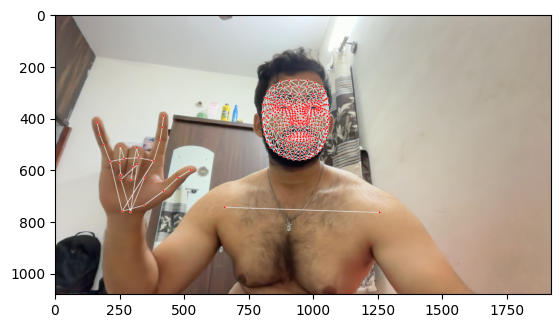

In [15]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Extract Keypoint Values

In [16]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

# Setup Folders for Collection

In [17]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['cat', 'food', 'help'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 30

In [18]:
signs = ['cat','food','help']

parent_folder = 'MP_Data'

if not os.path.exists(parent_folder):
    os.mkdir(parent_folder)
    for sign in signs:
        sign_folder = os.path.join(parent_folder, sign)
        os.mkdir(sign_folder)
        for i in range(30):
            subfolder = os.path.join(sign_folder, str(i))
            os.mkdir(subfolder)


# Collect Keypoint Values for Training and Testing

# Install into the current Python environment used by your notebook
python3 -m pip install --upgrade pip
python3 -m pip install opencv-python mediapipe scikit-learn matplotlib
# Quick check
python3 -c "import cv2; print('cv2 version:', cv2.__version__)"


In [19]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import os
import time

In [20]:
import numpy as np

actions = np.array(['cat', 'food', 'help'])  # Define your actions/signs here
no_sequences = 30       # Number of videos per action
sequence_length = 30    # Frames per video

DATA_PATH = os.path.join('MP_Data')
os.makedirs(DATA_PATH, exist_ok=True)


In [21]:
# Ensure actions and collection parameters exist in this kernel (safe-guard)
import numpy as np
import os
if 'actions' not in globals():
    actions = np.array(['cat', 'food', 'help'])
if 'DATA_PATH' not in globals():
    DATA_PATH = os.path.join('MP_Data')
    os.makedirs(DATA_PATH, exist_ok=True)
if 'no_sequences' not in globals():
    no_sequences = 30
if 'sequence_length' not in globals():
    sequence_length = 30
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

I0000 00:00:1763645360.989417  431033 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1763645361.041134  448968 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645361.044413  448968 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645361.045141  448966 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645361.045267  448973 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763645361.045372  448974 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support 

In [22]:
cap.release()
cv2.destroyAllWindows()

# Preprocess Data and Create Labels and Features

In [23]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [24]:
label_map = {label:num for num, label in enumerate(actions)}

In [25]:
label_map

{np.str_('cat'): 0, np.str_('food'): 1, np.str_('help'): 2}

In [26]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [27]:
X = np.array(sequences)

In [28]:
y = to_categorical(labels).astype(int)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

# Build and Train LSTM Neural Network

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [31]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)
#While training access tensorboard
#tensorboard --logdir=.

In [32]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

/opt/homebrew/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [36]:
model.fit(X_train, y_train, epochs=2000, callbacks=[tb_callback])

ImportError: cannot import name 'Tensor' from 'tensorflow.python.framework.ops' (/opt/homebrew/lib/python3.9/site-packages/tensorflow/python/framework/ops.py)

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │       442,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,675 (2.28 MB)

 Trainable params: 596,675 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
!pip install visualkeras


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621


In [39]:
{
  "cells": [
    {
      "cell_type": "code",
      "metadata": {
        "language": "python"
      },
      "source": [
        "# Ensure model is built before visualizing (fix AttributeError from visualkeras)\n",
        "import numpy as np\n",
        "import tensorflow as tf\n",
        "from PIL import ImageFont\n",
        "\n",
        "# Adjust these if your model's time-steps/features differ\n",
        "expected_time_steps = 30\n",
        "expected_features = 1662\n",
        "\n",
        "if not getattr(model, 'built', False):\n",
        "    print('Model not built — calling model.build(...) to populate layer shapes')\n",
        "    model.build(input_shape=(None, expected_time_steps, expected_features))\n",
        "else:\n",
        "    print('Model already built — proceeding to visualize')\n",
        "\n",
        "# Create font if you used one earlier, otherwise visualkeras will use defaults\n",
        "try:\n",
        "    font = ImageFont.truetype(\"Arial.ttf\", 12)\n",
        "except Exception:\n",
        "    font = None\n",
        "\n",
        "try:\n",
        "    if font is not None:\n",
        "        visualkeras.layered_view(model, legend=True, font=font, spacing=100)\n",
        "    else:\n",
        "        visualkeras.layered_view(model, legend=True, spacing=100)\n",
        "except AttributeError as e:\n",
        "    print('visualkeras AttributeError:', e)\n",
        "    print('Attempting to build model and retry...')\n",
        "    model.build(input_shape=(None, expected_time_steps, expected_features))\n",
        "    visualkeras.layered_view(model, legend=True, font=font, spacing=100)\n"
      ]
    }
  ]
}

{'cells': [{'cell_type': 'code',
   'metadata': {'language': 'python'},
   'source': ['# Ensure model is built before visualizing (fix AttributeError from visualkeras)\n',
    'import numpy as np\n',
    'import tensorflow as tf\n',
    'from PIL import ImageFont\n',
    '\n',
    "# Adjust these if your model's time-steps/features differ\n",
    'expected_time_steps = 30\n',
    'expected_features = 1662\n',
    '\n',
    "if not getattr(model, 'built', False):\n",
    "    print('Model not built — calling model.build(...) to populate layer shapes')\n",
    '    model.build(input_shape=(None, expected_time_steps, expected_features))\n',
    'else:\n',
    "    print('Model already built — proceeding to visualize')\n",
    '\n',
    '# Create font if you used one earlier, otherwise visualkeras will use defaults\n',
    'try:\n',
    '    font = ImageFont.truetype("Arial.ttf", 12)\n',
    'except Exception:\n',
    '    font = None\n',
    '\n',
    'try:\n',
    '    if font is not Non

In [40]:
# Safe visualizer: ensure model is built before calling visualkeras
import visualkeras
from PIL import ImageFont
import numpy as np
# Adjust these if your model's time-steps/features differ
expected_time_steps = 30
expected_features = 1662
# Font fallback
try:
    font = ImageFont.truetype("/Library/Fonts/Arial.ttf", 12)
except Exception:
    font = None
# Build model if necessary
if not getattr(model, 'built', False):
    try:
        print('Model not built — calling model.build(...) to populate layer shapes')
        model.build(input_shape=(None, expected_time_steps, expected_features))
    except Exception as e:
        print('model.build failed:', e)
# Try visualizing
try:
    if font is not None:
        visualkeras.layered_view(model, legend=True, font=font, spacing=100)
    else:
        visualkeras.layered_view(model, legend=True, spacing=100)
except AttributeError as e:
    print('visualkeras AttributeError:', e)
    try:
        model.build(input_shape=(None, expected_time_steps, expected_features))
        if font is not None:
            visualkeras.layered_view(model, legend=True, font=font, spacing=100)
        else:
            visualkeras.layered_view(model, legend=True, spacing=100)
    except Exception as e2:
        print('visualizer retry failed:', e2)


visualkeras AttributeError: 'LSTM' object has no attribute 'output_shape'
visualizer retry failed: 'LSTM' object has no attribute 'output_shape'


/opt/homebrew/lib/python3.9/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


# Make Predictions

In [41]:
res = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


In [42]:
actions[np.argmax(res[4])]

np.str_('food')

In [43]:
actions[np.argmax(y_test[4])]

np.str_('help')

# Save Weights

In [44]:
model.save_weights('./model.weights.h5')


In [45]:
model.save('./model.h5')
# Keras requires the weights filename to end with `.weights.h5` when using save_weights()
model.save_weights('./model.weights.h5')

In [46]:
del model

In [47]:
import tensorflow as tf
model = tf.keras.models.load_model('model.h5')

In [58]:
'''model.load_weights('model_weights.h5', by_name=True, skip_mismatch=True)
print("Loaded matching weights; mismatched layers were skipped (you must train final layers)'''

'model.load_weights(\'model_weights.h5\', by_name=True, skip_mismatch=True)\nprint("Loaded matching weights; mismatched layers were skipped (you must train final layers)'

In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │       442,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,677 (2.28 MB)

 Trainable params: 596,675 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [59]:
model.load_weights('model_weights.h5')

# Evaluation using Confusion Matrix

In [60]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [61]:
yhat = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [62]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [63]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[2, 0],
        [3, 0]],

       [[0, 3],
        [0, 2]]])

In [64]:
accuracy_score(ytrue, yhat)

0.4

# Realtime Test

In [65]:
from scipy import stats

In [66]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [67]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

I0000 00:00:1763646254.818898  431033 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1763646254.872506  468107 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646254.879279  468107 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646254.880042  468110 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646254.880133  468111 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646254.880548  468109 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support 

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [68]:
!pip install numpy --upgrade

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621


In [70]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import tensorflow as tf

signs = ['hello', 'thanks', 'iloveyou']
actions = np.array(['hello', 'thanks', 'iloveyou'])


mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR-CONVERSION BGR-to-RGB
    image.flags.writeable = False                  # Convert image to not-writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Convert image to writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR-COVERSION RGB-to-BGR
    return image, results

colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 
    
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])
    
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

model = tf.keras.models.load_model('model.h5')
model.load_weights('model_weights.h5')
model.summary()

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        #print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            #print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            #image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        #print(sentence)
        #word = sentence[-1:]
        #convert_to_audio(word[0]) if (len(word) != 0) else print("word not detected yet")
        #convert_to_audio(word[0])
        
        # Show to screen
        cv2.imshow('Realtime LSTM Sign Language Detection', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │       442,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,677 (2.28 MB)

 Trainable params: 596,675 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

I0000 00:00:1763646513.683693  431033 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1763646513.739518  525888 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646513.742575  525888 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646513.743722  525891 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646513.743800  525892 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763646513.744032  525890 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━